In [2]:
# Import libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('data.csv', encoding='latin-1')

# First look at the data
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
# Check data info and missing values
print("Data Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Basic Statistics:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
# Clean the data
# 1. Remove rows with missing CustomerID
df_clean = df.dropna(subset=['CustomerID'])

# 2. Remove cancelled orders (negative quantity)
df_clean = df_clean[df_clean['Quantity'] > 0]

# 3. Remove negative prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 4. Create a Total Sales column
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Check what's left
print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 541909
Clean rows: 397884
Rows removed: 144025


In [5]:
# Convert InvoiceDate to proper date format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Extract Month and Year from the date
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Year'] = df_clean['InvoiceDate'].dt.year

# Total revenue by month
monthly_revenue = df_clean.groupby(['Year', 'Month'])['TotalSales'].sum().reset_index()
monthly_revenue.columns = ['Year', 'Month', 'Revenue']

print("Monthly Revenue:")
print(monthly_revenue)

Monthly Revenue:
    Year  Month      Revenue
0   2010     12   572713.890
1   2011      1   569445.040
2   2011      2   447137.350
3   2011      3   595500.760
4   2011      4   469200.361
5   2011      5   678594.560
6   2011      6   661213.690
7   2011      7   600091.011
8   2011      8   645343.900
9   2011      9   952838.382
10  2011     10  1039318.790
11  2011     11  1161817.380
12  2011     12   518192.790


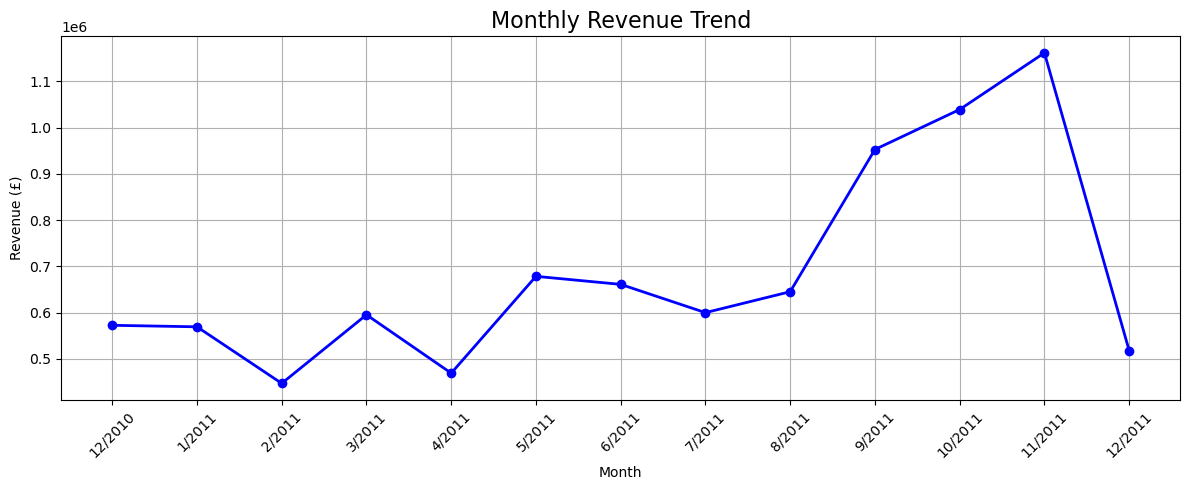

In [6]:
import matplotlib.pyplot as plt

# Create a label like "Jan 2011" for each row
monthly_revenue['Period'] = monthly_revenue['Month'].astype(str) + '/' + monthly_revenue['Year'].astype(str)

# Plot the chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['Period'], monthly_revenue['Revenue'], 
         marker='o', color='blue', linewidth=2)

plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

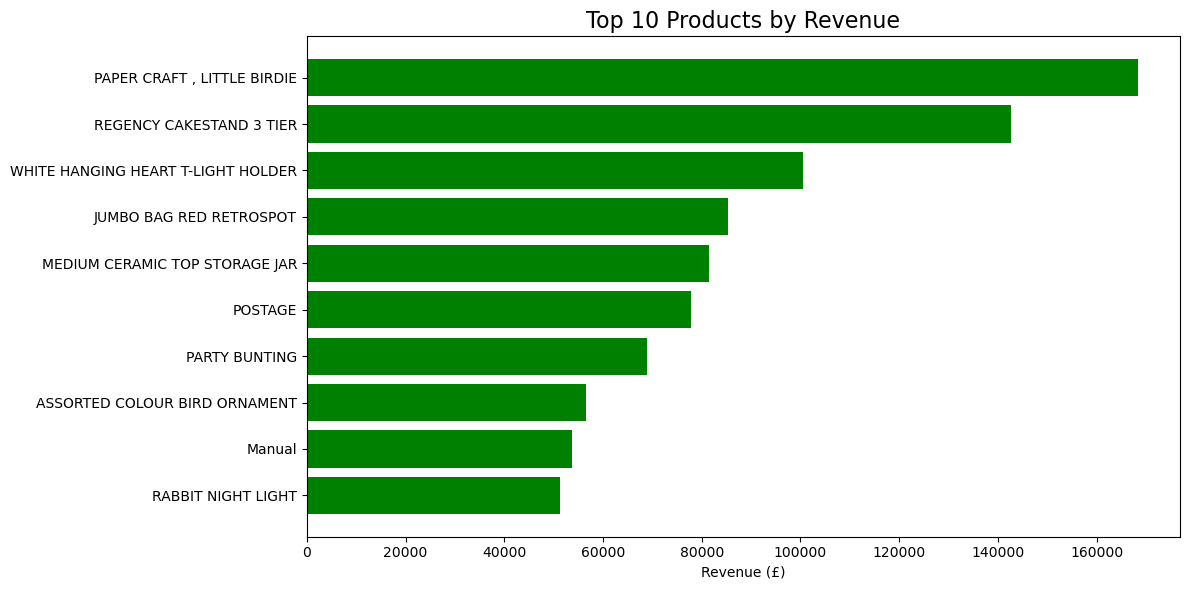

                              Product    Revenue
0         PAPER CRAFT , LITTLE BIRDIE  168469.60
1            REGENCY CAKESTAND 3 TIER  142592.95
2  WHITE HANGING HEART T-LIGHT HOLDER  100448.15
3             JUMBO BAG RED RETROSPOT   85220.78
4      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
5                             POSTAGE   77803.96
6                       PARTY BUNTING   68844.33
7       ASSORTED COLOUR BIRD ORNAMENT   56580.34
8                              Manual   53779.93
9                  RABBIT NIGHT LIGHT   51346.20


In [7]:
# Top 10 products by revenue
top_products = df_clean.groupby('Description')['TotalSales'].sum()
top_products = top_products.sort_values(ascending=False).head(10).reset_index()
top_products.columns = ['Product', 'Revenue']

# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_products['Product'], top_products['Revenue'], color='green')
plt.title('Top 10 Products by Revenue', fontsize=16)
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_products)

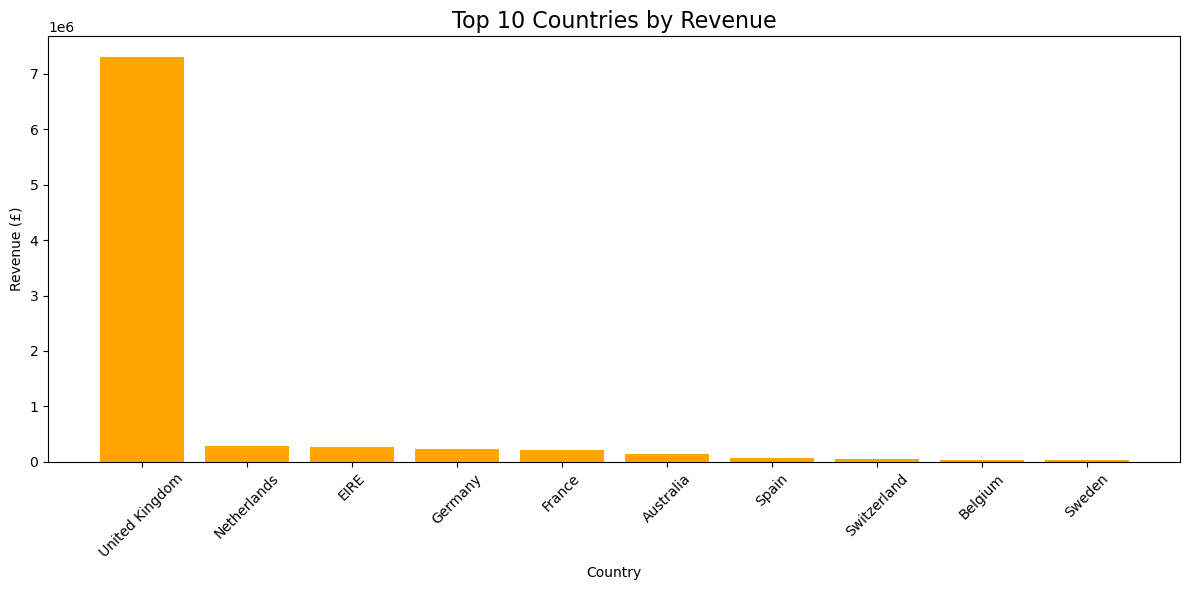

          Country      Revenue
0  United Kingdom  7308391.554
1     Netherlands   285446.340
2            EIRE   265545.900
3         Germany   228867.140
4          France   209024.050
5       Australia   138521.310
6           Spain    61577.110
7     Switzerland    56443.950
8         Belgium    41196.340
9          Sweden    38378.330


In [8]:
# Top 10 countries by revenue
top_countries = df_clean.groupby('Country')['TotalSales'].sum()
top_countries = top_countries.sort_values(ascending=False).head(10).reset_index()
top_countries.columns = ['Country', 'Revenue']

# Plot
plt.figure(figsize=(12, 6))
plt.bar(top_countries['Country'], top_countries['Revenue'], color='orange')
plt.title('Top 10 Countries by Revenue', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(top_countries)

In [9]:
# Save clean data for future use
df_clean.to_csv('ecommerce_clean.csv', index=False)
print("Clean data saved successfully!")

Clean data saved successfully!
